# 01 Analyse des proxies de surface
---
## Objectifs 
Ce notebook analyse les indicateurs de surface SST, SSS et SSH dans l'Atlantique Nord afin d'identifier les principales structures de surface liées à la circulation de l'Atlantique Nord.

>**RMQ:** 
>L'objectif n'est pas de mesurer directement l'AMOC, mais de caractériser les signatures de surface liées à la répartition de la chaleur, aux contrastes de salinité et à la circulation géostrophique.
---
## Plan : 
### I. État moyen et variabilité saisonnière de la surface de l'océan Atlantique Nord 
- Climatologie hivernale (DJA)
- Climatologie estivale (JJA)
- Amplitude saisonnière de la SST
- Amplitude saisonnière de la SSS
### II. Localisation des fronts océaniques
- Étude du gradient SSH 

### III. Variabilité Résiduelle 
- Variabilité résiduelle de la SST 
- Variabilité résiduelle de la SSS 
- Variabilité résiduelle de la SSH 
### IV. Bilan 

---
## Progression du projet Git-hub 
- 🟦 01 Analyse des proxies de surface *(vous êtes ici)*
- ⬜ 02 Impact de la résolution spatiale
- ⬜ 03 Conclusion
---


## I. État moyen de l'océan

### Axe d'analyse : 

Que révèlent les champs moyens de SST, SSS et SSH sur la circulation de surface de l'Atlantique Nord ? Et quelles régions de l'Atlantique Nord présentent les plus fortes variations saisonnières de température et de salinité ?

### Méthode

Les climatologies hivernales (DJF) et estivales (JJA) sont calculées à partir des moyennes mensuelles de la période 2015–2024.

L'amplitude saisonnière est calculée à partir de la climatologie mensuelle (2015–2024) en faisant la différence entre les valeurs maximales et minimales observées:

$$
A=\max\left(\overline{X}_{\mathrm{mois}}\right)-\min\left(\overline{X}_{\mathrm{mois}}\right)
$$

avec :

- $X$ = SST, SSS ou SSH

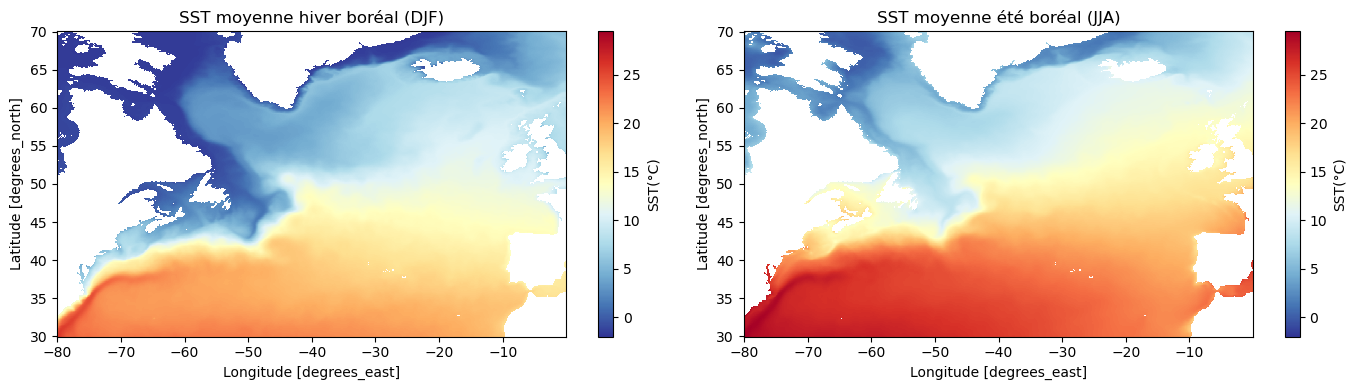

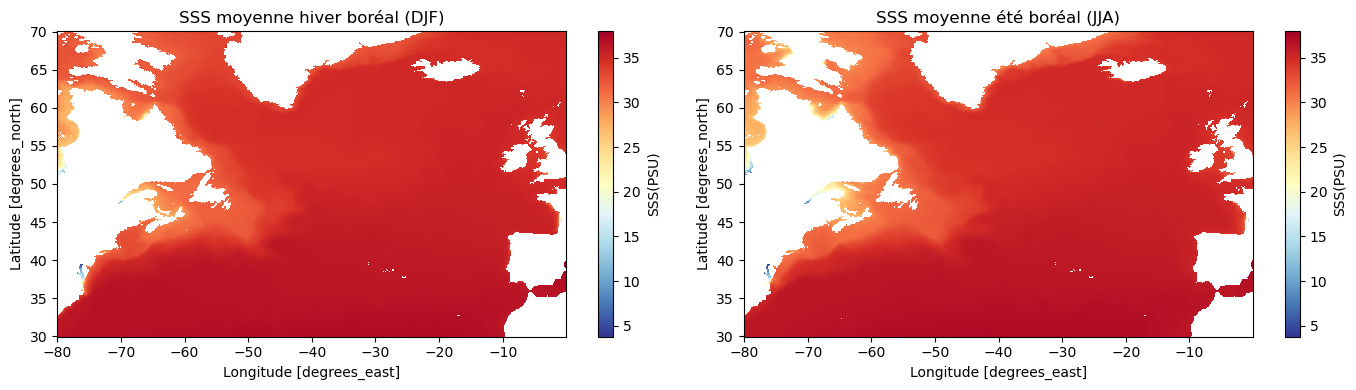

In [2]:
import fonction as fct
sst, sss, ssh = fct.extraction_proxies()

#Etude SST
sst_hiver = fct.moyenne_saisonniere(sst, "DJF")
sst_ete = fct.moyenne_saisonniere(sst, "JJA")
#fct.cartes(sst_hiver,sst_ete,"SST moyenne hiver boréal (DJF)","SST moyenne été boréal (JJA)",cmap="RdYlBu_r",titre_cbar="SST(°C)")
#fct.carte_show(carte1=sst_hiver,carte2=sst_ete,titre1="SST moyenne hiver boréal (DJF)",titre1_cbar="SST(°C)",
              # titre2="SST moyenne été boréal (JJA)",titre2_cbar="SST(°C)"
               #,cmap="RdYlBu_r", figsize=(14,4), same_scale=True)

#Etude SSS
vmin = float(sss.quantile(0.01)) 
vmax = float(sss.quantile(0.99)) 
sss_hiver = fct.moyenne_saisonniere(sss, "DJF")
sss_ete = fct.moyenne_saisonniere(sss, "JJA")


#fct.cartes(sss_hiver,sss_ete,"SSS moyenne hiver boréal (DJF)","SSS moyenne été boréal (JJA)",cmap="RdYlBu_r",titre_cbar="SSS(PSU)")
fct.carte(carte1=sst_hiver,carte2=sst_ete,titre1="SST moyenne hiver boréal (DJF)",titre1_cbar="SST(°C)",titre2="SST moyenne été boréal (JJA)",titre2_cbar="SST(°C)",cmap="RdYlBu_r", figsize=(14,4), same_scale=True)

fct.carte(carte1=sss_hiver,carte2=sss_ete,titre1="SSS moyenne hiver boréal (DJF)",titre1_cbar="SSS(PSU)",titre2="SSS moyenne été boréal (JJA)",titre2_cbar="SSS(PSU)",cmap="RdYlBu_r", figsize=(14,4), same_scale=True)


### Interprétation

Les cartes mettent en évidence le Gulf Stream, les eaux subtropicales chaudes et salées, ainsi que les eaux froides et moins salées des hautes latitudes. Les trois variables apportent des informations complémentaires sur la circulation de surface.

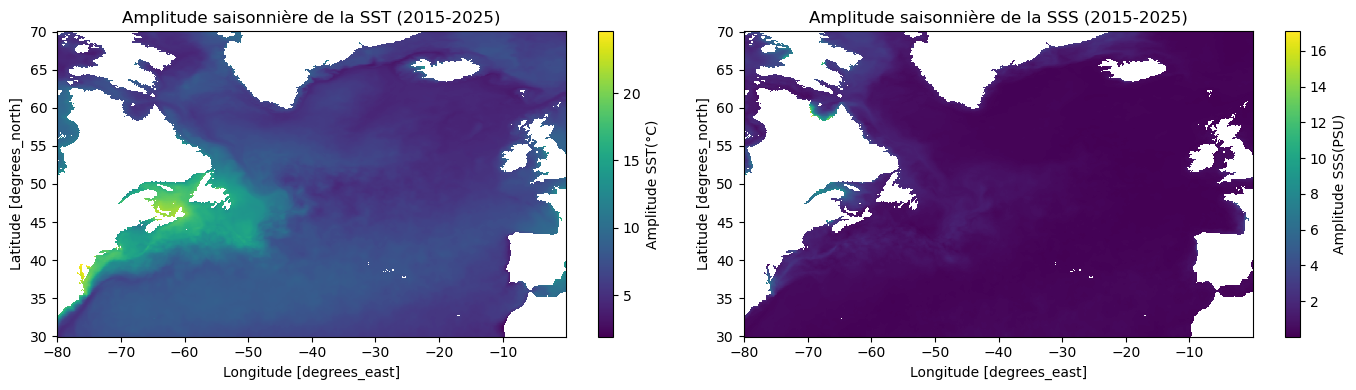

In [2]:
# Amplitude saisonnière SST
amplitude_sst = fct.amplitude_saisonniere(sst)

# Amplitude saisonnière SSS
amplitude_sss = fct.amplitude_saisonniere(sss)

fct.carte(carte1=amplitude_sst,carte2=amplitude_sss,titre1="Amplitude saisonnière de la SST (2015-2025)",titre1_cbar="Amplitude SST(°C)",titre2="Amplitude saisonnière de la SSS (2015-2025)",titre2_cbar="Amplitude SSS(PSU)",cmap="viridis", figsize=(14,4))

### Interprétation

Ces figures mettent en évidence la variabilité saisonnière de la SST et nous permettent d'établir quatre constats : 
- la variabilité annuelle n’est pas uniforme dans l’Atlantique Nord ;
- la zone subtropicale est fortement liée aux échanges air-mer et au chauffage estival, la rendant plus sujette à des phénomènes d'évaporation, ce qui contribue au maintien des fortes salinités dans cette région. 
- La zone subpolaire présente également une forte variabilité. La diminution de la salinité est cohérente avec les apports d’eau douce liés à la fonte des glaces. 
- Le Gulf Stream n'affiche pas de grande variabilité saisonnière, mais demeure identifiable tout au long de l’année, ce qui confirme l'importance majeure de cette structure océanique.

## II. Localisation des fronts océaniques 

### Axe d'analyse : 

Où se situent les principaux fronts dynamiques et courants de surface de l’Atlantique Nord ?

### Méthode

Le gradient de la hauteur de surface de la mer permet d’identifier les zones où la SSH varie rapidement dans l’espace. 
Ces gradients sont liés aux courants géostrophiques : un fort gradient de SSH indique une pente importante de la surface océanique, donc une circulation de surface plus intense.

$$|\nabla SSH|=\sqrt{\left(\frac{\partial \overline{SSH}}{\partial x}\right)^2+\left(\frac{\partial \overline{SSH}}{\partial y}\right)^2}$$



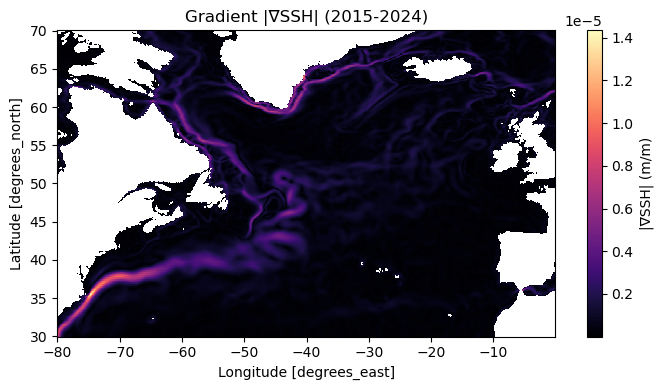

In [3]:
# SSH moyenne
ssh_moyenne = ssh.mean("time")

# Gradient moyen de SSH
gradient = fct.gradient(ssh_moyenne)

fct.carte(carte1=gradient, titre1="Gradient |∇SSH| (2015-2024)", cmap="magma", titre1_cbar="|∇SSH| (m/m)", figsize=(7,4))

### Interprétation

La représentation illustre que le Gulf Stream possède un fort gradient horizontal de SSH or d'après la relation d'équilibre géostrophique :
 
$$u_g=-\frac{g}{f}\frac{\partial SSH }{\partial y}$$

$$v_g=\frac{g}{f}\frac{\partial SSH}{\partial x}$$

avec : 
- $u_g$ : la composante zonale 
- $v_g$ : la composante méridienne
- $g$ : l'accélération de la pesanteur 
- $f$ : le paramètre de Coriolis ;

Un courant rapide est associé à un fort gradient horizontal. Par conséquent, le Gulf Stream est un courant rapide.

Cette figure confirme que le gradient de SSH est un indicateur pertinent pour localiser les principaux courants géostrophiques de l'Atlantique Nord. Dans la suite de l'étude, cette méthode sera utilisée pour étudier l'impact de la résolution spatiale


## III. Variabilité résiduelle

### Axe d'analyse : 
Après le retrait du cycle saisonnier, où la circulation océanique présente-t-elle encore une forte variabilité ?

### Méthode

La climatologie mensuelle est d'abord calculée pour chaque mois de la période 2015–2025.

Les anomalies sont ensuite obtenues en soustrayant la climatologie mensuelle à chaque observation :

$$
X'(t)=X(t)-X_{climatologie}
$$

Enfin, la variabilité résiduelle est estimée à l'aide de l'écart-type des anomalies.


/Users/seph/miniforge3/envs/amoc/lib/python3.11/site-packages/numpy/lib/_nanfunctions_impl.py:1997: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/Users/seph/miniforge3/envs/amoc/lib/python3.11/site-packages/numpy/lib/_nanfunctions_impl.py:1997: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/Users/seph/miniforge3/envs/amoc/lib/python3.11/site-packages/numpy/lib/_nanfunctions_impl.py:1997: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


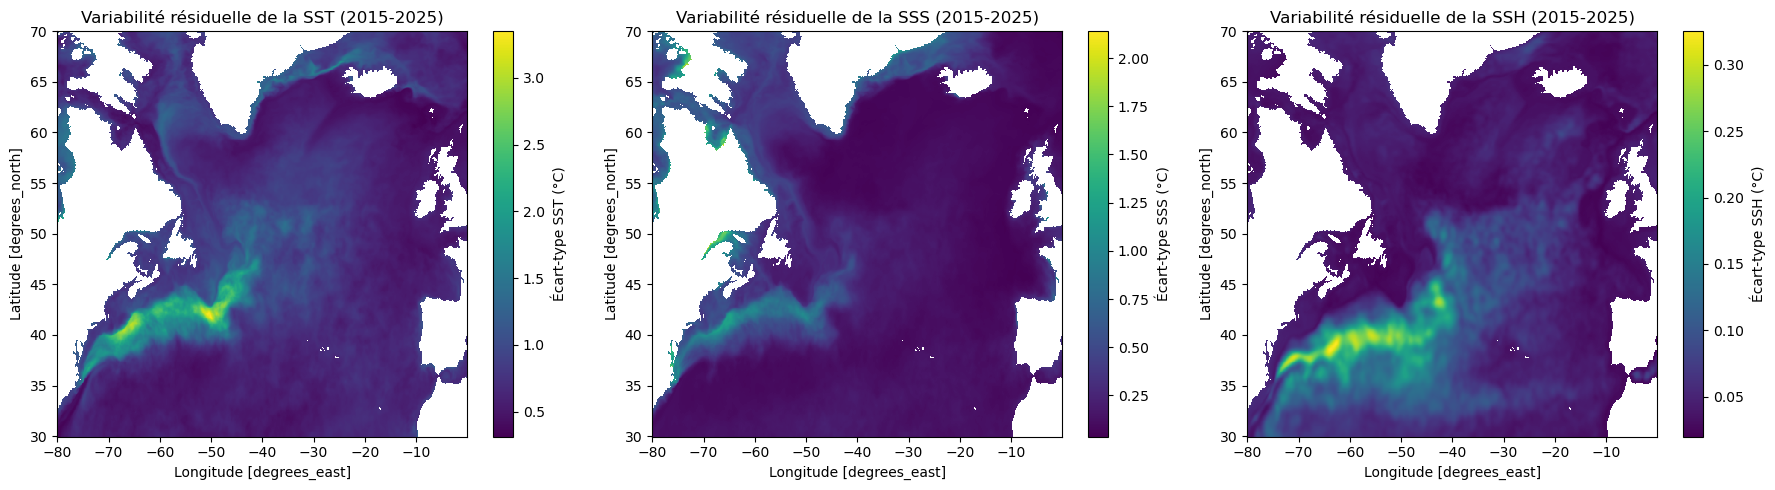

In [5]:
# Variabilité résiduelle SST
variabilite_sst = fct.variabilite_residuelle(sst)

# Variabilité résiduelle SSS
variabilite_sss = fct.variabilite_residuelle(sss)

# Variabilité résiduelle SSH
variabilite_ssh = fct.variabilite_residuelle(ssh)


fct.carte(carte1=variabilite_sst,titre1="Variabilité résiduelle de la SST (2015-2025)",titre1_cbar="Écart-type SST (°C)",
               carte2=variabilite_sss,titre2="Variabilité résiduelle de la SSS (2015-2025)",titre2_cbar="Écart-type SSS (°C)",
               carte3=variabilite_ssh,titre3="Variabilité résiduelle de la SSH (2015-2025)",titre3_cbar="Écart-type SSH (°C)",
               cmap="viridis", figsize=(18,5))

### Interprétation 

Cette analyse met en évidence les régions où les fluctuations dépassent le simple cycle saisonnier : 
- la coïncidence des maxima de SST et SSS et de SSH suggère que la variabilité résiduelle est dominée par la dynamique du Gulf Stream. 
- Les déplacements du courant, ses méandres et les tourbillons qu’il génère transportent des masses d’eaux chaudes et salées d’origine subtropicale en direction du Nord de l'Atlantique. 


## Bilan 
La première partie de ce projet met en évidence que la région du Gulf Stream est l'une des zones les plus dynamiques de l'Atlantique Nord. Elle se caractérise par de forts gradients de température et de salinité, une circulation géostrophique intense. Cette région est également régie par de nombreux tourbillons méso-échelle marqués. 
